## Model Training

In [1]:
# import libraries for deep learning tasks
import tensorflow as tf 
from tensorflow.keras import layers, models 
from tensorflow.keras.preprocessing import image 
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# import libraries for data processing and visualisation tasks
import os 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

# import tools for model development tasks
from model_development_tools import data_augmentation

Approach: 
+ Data Preparation
+ Building input Pipeline
+ Model Selection
+ Model Training


In [2]:
# load dataset 
mobile_data = pd.read_csv("image_dataset.csv",index_col=0)
mobile_data.head(10)

,Image_file,Labels,Model,Company
0,image_000.jpg,Samsung SM-A156B Galaxy A15 Dual SIM 5G 4GB RA...,SM-A156B Galaxy,Samsung
1,image_001.jpg,Samsung SM-A556B Galaxy A55 5G Dual SIM 8GB 12...,SM-A556B Galaxy,Samsung
2,image_002.jpg,Motorola Moto G54 256GB Blue 5G Android Smartp...,Moto G54,Motorola
3,image_003.jpg,Xiaomi 14 Ultra 5G 16GB/512GB White (White) Du...,14 Ultra,Xiaomi
4,image_004.jpg,Samsung Galaxy S20 FE 5G 6GB/128GB Purple (Lav...,Galaxy S20,Samsung
5,image_005.jpg,Samsung Galaxy S22+ 5G 8GB/128GB Black (Phanto...,Galaxy S22+,Samsung
6,image_006.jpg,Samsung Galaxy A55 Smartphone 128GB 5G Midnigh...,Galaxy A55,Samsung
7,image_007.jpg,"Samsung Smartphone Galaxy S20, 5G, 12GB + 128G...",Smartphone Galaxy,Samsung
8,image_008.jpg,"Samsung Galaxy A03 Smartphone 64GB, 4GB RAM, D...",Galaxy A03,Samsung
9,image_009.jpg,SAMSUNG S20 ULTRA 128GB Phone - Cosmic gray\n,S20 ULTRA,Samsung


## Data Preparation

+ Resizing images 
+ Data Augmentation
+ Feature Encoding: Label Data

In [3]:
# path of selected images 
image_path = "D:\\Machine_Learning\\Portfolio_Project_Machine_Learning\\Mobile_Phone_Recognition\\datasets\\source_images"
image_src = os.path.join(image_path, "image_001.jpg")
print(f"Image source: {image_src}")

# Apply data augmentation to a single image
img = image.load_img(image_src)
img_array = image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Add batch dimension (1, height, width, channels)

print(f"Image: {img_array.shape}")

Image source: D:\Machine_Learning\Portfolio_Project_Machine_Learning\Mobile_Phone_Recognition\datasets\source_images\image_001.jpg
Image: (1, 320, 250, 3)


In [4]:
# resizing images 
image_size = (330,330)
batch_size = 32

# define the paths: training and testing sets
dataset_path =  "D:\\Machine_Learning\\Portfolio_Project_Machine_Learning\\Mobile_Phone_Recognition\\datasets\\distributed_images"
datasets = os.listdir(dataset_path) # ['test', 'train']
train_folder = os.path.join(dataset_path, datasets[1])
test_folder = os.path.join(dataset_path, datasets[0])

print(f"Train folder: {train_folder}")
print(f"Test folder: {test_folder}")

Train folder: D:\Machine_Learning\Portfolio_Project_Machine_Learning\Mobile_Phone_Recognition\datasets\distributed_images\train
Test folder: D:\Machine_Learning\Portfolio_Project_Machine_Learning\Mobile_Phone_Recognition\datasets\distributed_images\test


In [5]:
# augment the train and test images
train_generator, test_generator = data_augmentation(train_path=train_folder, 
                                                    test_path=test_folder, 
                                                    img_size=image_size,
                                                    rotation=30)


Found 276 images belonging to 8 classes.
Found 191 images belonging to 8 classes.
Shape of train images: (330, 330, 3)
Number of training samples: 276
Number of test samples: 191


In [6]:
# apply data augmentation on mobile phone images
# inspect the images with different degrees
def image_inspection(update_degrees: int, update_img_size: tuple): 
  # re-augment the train and test images
  train_generator, test_generator = data_augmentation(train_path=train_folder, 
                                                    test_path=test_folder, 
                                                    img_size=update_img_size,
                                                    rotation=update_degrees)
  # get the images and labels 
  images, labels = next(train_generator)

  # get class indices from one-hot encoded labels
  class_indices = train_generator.class_indices
  class_names = {v:k for k, v in class_indices.items()}

  # convert one-hot labels to class indices
  label_indices = labels.argmax(axis=1)

  # plot a few examples
  plt.figure(figsize=(10, 10))
  for i in range(9):
    plt.subplot(3,3, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[label_indices[i]])
    plt.axis('off')
  plt.show()

  return images, labels

In [7]:
# test case: image size and degrees for image rotation
rotations = [30, 20, 15, 10]
img_sizes = [(128, 128),(256, 256),(300,300),(315,315)]

Found 276 images belonging to 8 classes.
Found 191 images belonging to 8 classes.
Shape of train images: (330, 330, 3)
Number of training samples: 276
Number of test samples: 191


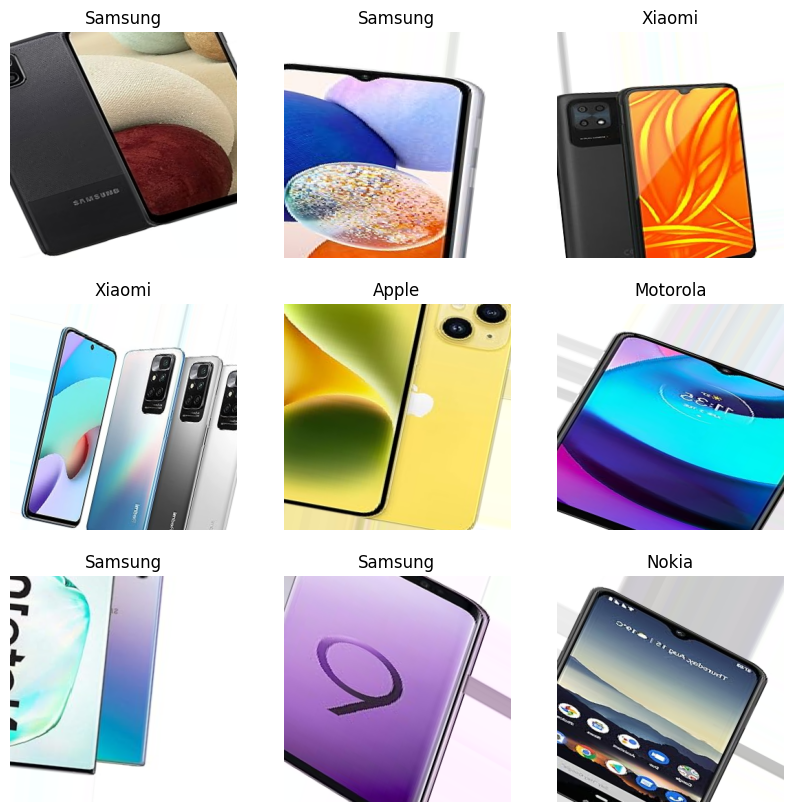

In [8]:
# inspect images with different rotation degrees
# image_inspection(degrees=20) # 20 degrees
images, labels = image_inspection(update_degrees=30, update_img_size=img_sizes[1]) # 30 degrees
# labels2 = image_inspection(update_degrees=30, update_img_size=img_sizes[0])

## Model Training

In [9]:
from model_selection import VGGModel
from model_selection import CNNModel

Approach: Model Training

+ Model Building: through import pre-model training
+ Model Selection
+ Training the model: VGG-model and ResNet-model
+ Model Evaluation: check performance of model through metrics

### Model Building and Training

In [10]:
# number of samples for test and train set
train_set_num = train_generator.samples
image_size_shape = (train_set_num, 32, 32, 3)

In [11]:
dimension, num_classes = labels.shape
print(f"Number of Mobile Phone Classes: {num_classes}")
print(f"Dimension: {dimension}")

Number of Mobile Phone Classes: 8
Dimension: 32


In [12]:
# define parameters for compiling the model 
optimizer = "adam"
loss = "categorical_crossentropy"
metrics=['accuracy']

# build the models 
cnn_model1 = CNNModel((3,3),(3,3),num_classes=num_classes)
vgg_model1 = VGGModel((3, 3), (3,3), num_classes=num_classes)

# compile the models
cnn_model1.compile(optimizer=optimizer, loss=loss, metrics=metrics)
# vgg_model1.compile(optimizer=optimizer, loss=loss, metrics=metrics)

In [13]:
def model_training(model): 
  # define list: number of epochs
  epochs = [5,10, 12, 15, 17, 20]
  steps_per_epoch = [100, 120, 140, 160]
  validation_steps = [50, 70, 90, 100]

  # train the model 1: cnn model 1
  model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=epochs[0],
    steps_per_epoch=steps_per_epoch[0],
    validation_steps=validation_steps[0]
  )

In [14]:
model_training(model=cnn_model1)

d:\Machine_Learning\Portfolio_Project_Machine_Learning\Mobile_Phone_Recognition\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
Shape after 1st block: (None, 110, 110, 32)
Shape after 2nd block: (None, 36, 36, 64)
Shape after 3rd block: (None, 12, 12, 128)
Shape after flatten: (None, 18432)
Shape after FC1: (None, 128)
Shape after output layer: (None, 8)
Shape after 1st block: (None, 110, 110, 32)
Shape after 2nd block: (None, 36, 36, 64)
Shape after 3rd block: (None, 12, 12, 128)
Shape after flatten: (None, 18432)
Shape after FC1: (None, 128)
Shape after output layer: (None, 8)
Shape after 1st block: (None, 110, 110, 32)
Shape after 2nd block: (None, 36, 36, 64)
Shape after 3rd block: (None, 12, 12, 128)
Shape after flatten: (None, 18432)
Shape after FC1: (None, 128)
Shape after output layer: (None, 8)
  9/100 ━━━━━━━━━━━━━━━━━━━━ 2:00 1s/step - accuracy: 0.3269 - loss: 1.9255

D:\User\LocalMachine\Python\Python3.12\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(value)


Shape after 1st block: (None, 110, 110, 32)
Shape after 2nd block: (None, 36, 36, 64)
Shape after 3rd block: (None, 12, 12, 128)
Shape after flatten: (None, 18432)
Shape after FC1: (None, 128)
Shape after output layer: (None, 8)
100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 127ms/step - accuracy: 0.4152 - loss: 1.7611 - val_accuracy: 0.4607 - val_loss: 1.6946
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 114ms/step - accuracy: 0.5220 - loss: 1.5256 - val_accuracy: 0.4503 - val_loss: 1.6479
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 14s 129ms/step - accuracy: 0.5203 - loss: 1.4989 - val_accuracy: 0.4503 - val_loss: 1.7763
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 119ms/step - accuracy: 0.5172 - loss: 1.4960 - val_accuracy: 0.4503 - val_loss: 1.6301
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 119ms/step - accuracy: 0.5351 - loss: 1.4386 - val_accuracy: 0.4607 - val_loss: 1.5747


## Model Prediction

In [15]:
from tensorflow.keras.models import load_model

+ Save the model after training
+ Load one random mobile image for predicting the model
+ Predict the image with the model

Check later: save_model()

In [16]:
# # save the model image
# def save_model(model, model_name, input_path): 
#   # define the constants: save a model
#   model_file = f"mobile_recognition_{model_name}.keras"
#   model_path = input_path
#   model_path = os.path.join(model_path, model_file)

#   # verify model successfully saved
#   if os.path.exists(model_path):
#     model.save(model_path)
#     print("Model saved successfully!")
#   else:
#       print("Model saving failed. Check the path.")
#       print(f"Path: {model_path}")

In [17]:
cnn_model1.save("model1.keras")